## Time Pattern Analysis

In [1]:
%run prepare.ipynb
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from copy import copy
from matplotlib.colors import PowerNorm
def show(title):
  plt.savefig(f'img/{title}.svg', bbox_inches='tight')
  plt.savefig(f'img/{title}.png', bbox_inches='tight', dpi=300)
  plt.show()

### Top Streaming Day

In [41]:
daily_totals = dated_streams.groupby('date').agg({'ms_played': 'sum'})
daily_totals.idxmax(), daily_totals.max()

(ms_played    2025-03-28
 dtype: object,
 ms_played    27659299
 dtype: int64)

### Heatmap of Streams by Day of Year

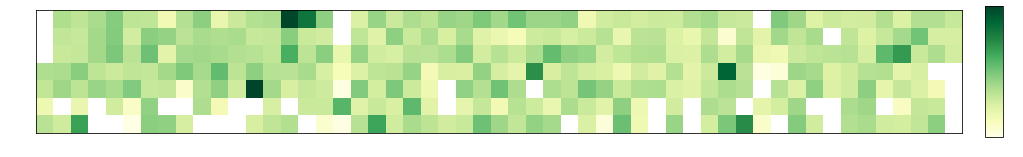

In [6]:
day_matrix.replace(0, np.nan, inplace=True)

cmap = copy(cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.rcParams["figure.figsize"] = (20,6)
plt.imshow(day_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))

ms = pd.date_range(start="2025-01", end="2025-12", freq='MS')
plt.xticks(ms.isocalendar()['week'],ms.strftime('%b'))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.4, pad=0.02, aspect=7)
cbar.ax.tick_params(color='white', labelcolor='white')
plt.tick_params(colors='white', which='both')
# plt.gcf().set_facecolor("white")

show('day_matrix')

### Heatmap of Streaming Time by Hour and Day

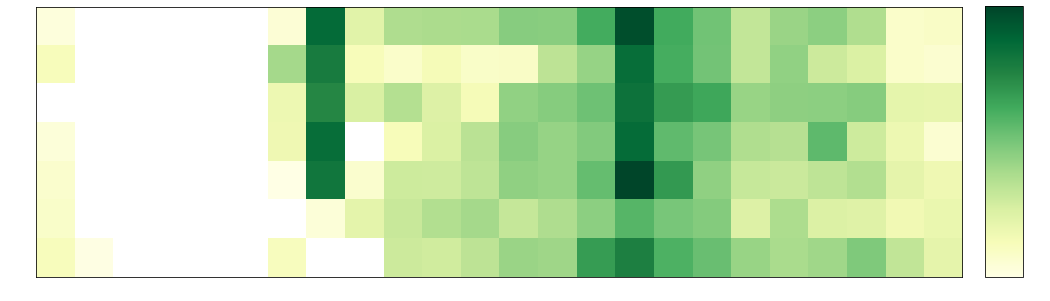

(15, 69.01087166666667)
('Monday', 58.78946583333333)


(13.869509722222222, (array([4]), array([15])))

In [129]:
hour_matrix.replace(0, np.nan, inplace=True)

cmap = copy(cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.imshow(hour_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))

plt.xticks(range(24))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.83, pad=0.02, aspect=7)
cbar.ax.tick_params(color='white', labelcolor='white')
plt.tick_params(colors='white', which='both')

# plt.gcf().set_facecolor("white")
show('hour_matrix')

# TODO: move
def max_sum(matrx, axis=0):
  axis_max = matrx.sum(axis=axis).idxmax()
  sum_value = matrx.sum(axis=axis)[axis_max]
  return axis_max, sum_value

print(max_sum(hour_matrix))
print(max_sum(hour_matrix, axis=1))
max_cell = hour_matrix.max().max()
max_cell, np.where(hour_matrix == max_cell)

### Streaming Time by Month (with average)

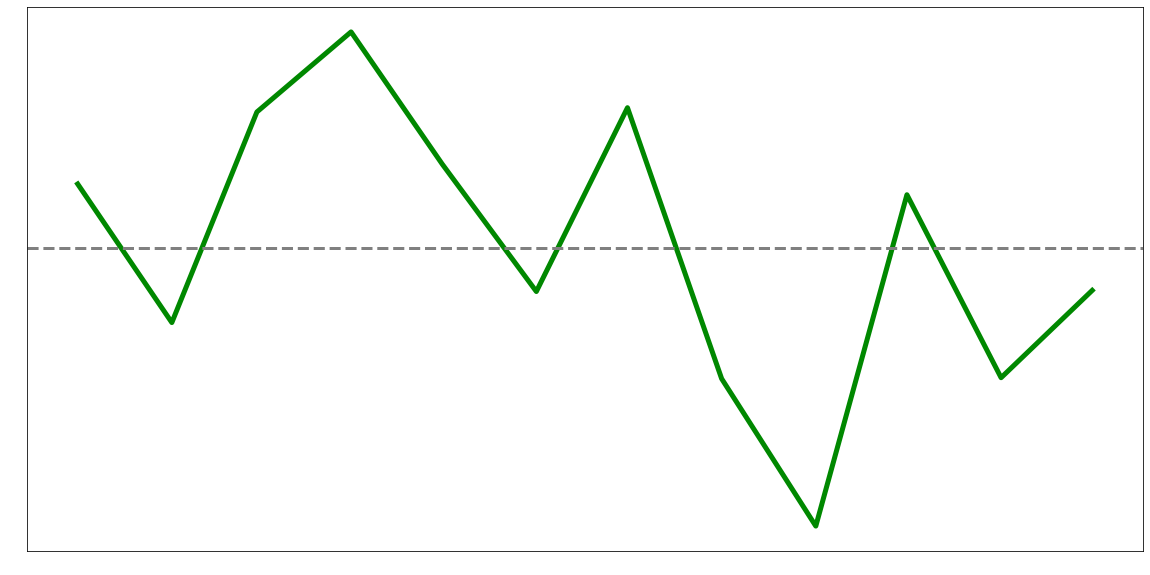

ts
2025-01-01    29.394169
2025-02-01    24.829040
2025-03-01    31.766065
2025-04-01    34.403855
2025-05-01    30.051381
2025-06-01    25.851686
2025-07-01    31.907472
2025-08-01    22.980130
2025-09-01    18.124423
2025-10-01    29.040500
2025-11-01    23.013232
2025-12-01    25.888965
Name: ms_played, dtype: float64

In [6]:
monthy_mins = monthly_stats.reset_index()
monthy_mins['ts'] = pd.to_datetime(monthy_mins['ts'])
monthy_mins = monthy_mins.set_index('ts').sort_index() 
this_year = monthy_mins.loc["2025"]["ms_played"] / MS2H
last_year = monthy_mins.loc["2024"]["ms_played"] / MS2H

fig, ax = plt.subplots()
ax.plot(this_year, lw=5, color='#080')
# ax.plot(this_year.index, last_year, color='lightblue')
plt.axhline(y=this_year.mean(), color='grey', linestyle='--', lw=3)
plt.rcParams["figure.figsize"] = (20,10)

ax.set_xticks(this_year.index, dated_months.strftime('%b'))
ax.patch.set_facecolor('none')
ax.tick_params(color='white', labelcolor='white')
# plt.gcf().set_facecolor("white")
show('monthly_mins_with_avg')
this_year

### Streaming Time by Month (vs. last year)

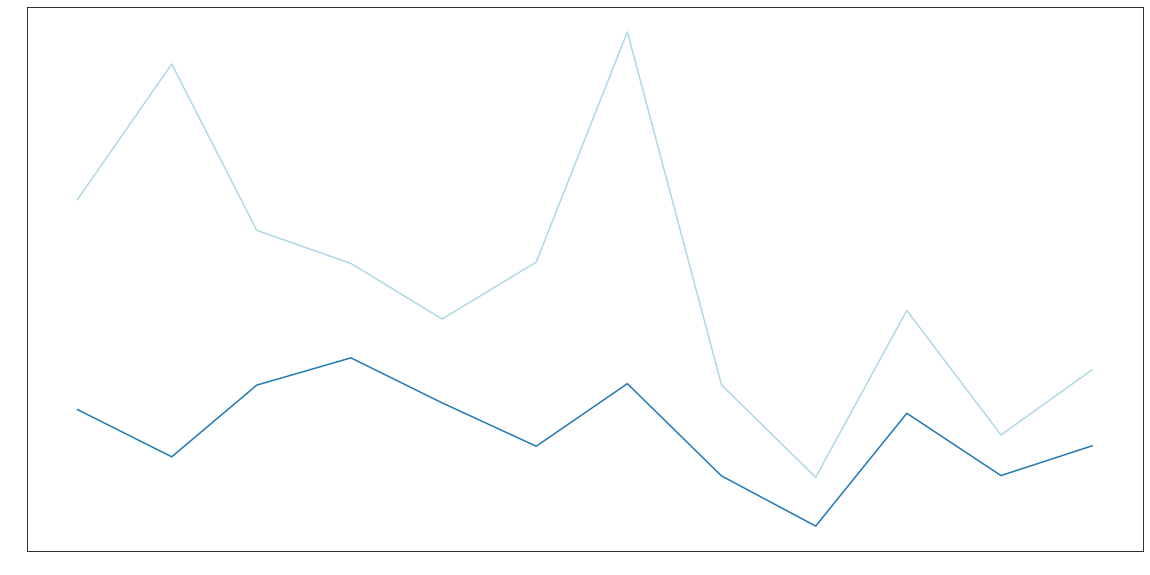

,this,yr change,mn change
0,29.39,-20.34 (-40.9%),-3.86 (-7.76%)
1,24.83,-38.01 (-60.49%),-4.57 (-7.27%)
2,31.77,-14.97 (-32.04%),6.94 (14.84%)
3,34.40,-9.14 (-20.99%),2.64 (6.06%)
4,30.05,-8.11 (-21.25%),-4.35 (-11.41%)
5,25.85,-17.82 (-40.8%),-4.2 (-9.62%)
6,31.91,-34.04 (-51.61%),6.06 (9.18%)
7,22.98,-8.8 (-27.69%),-8.93 (-28.09%)
8,18.12,-4.72 (-20.66%),-4.86 (-21.26%)
9,29.04,-9.95 (-25.53%),10.92 (27.99%)


In [9]:
fig, ax = plt.subplots()
ax.plot(this_year)

ax.plot(this_year.index, last_year, color='lightblue')
ax.set_xticks(this_year.index, dated_months.strftime('%b'))
ax.patch.set_facecolor('none')
ax.tick_params(color='white', labelcolor='white')

show('monthly_mins_vs_last_year')

month_comp = pd.DataFrame(zip(last_year, this_year), columns=('last', 'this'))
month_comp['yr diff'] = month_comp['this'] - month_comp['last']
month_comp['yr ratio'] = month_comp['yr diff'] / month_comp['last']  #1 - (month_comp['this'] / month_comp['last'])
month_comp['mn diff'] = month_comp['this'].diff(periods=1)
month_comp.loc[0]['mn diff'] = month_comp.loc[0]['this'] - month_comp.loc[11]['last']
month_comp['mn ratio'] = month_comp['mn diff'] / month_comp['last']

month_comp['yr change'] = round(month_comp['yr diff'], 2).astype(str) + " (" + round(month_comp['yr ratio'] * 100, 2).astype(str) + "%)"
month_comp['mn change'] = round(month_comp['mn diff'], 2).astype(str) + " (" + round(month_comp['mn ratio'] * 100, 2).astype(str) + "%)"
month_comp['this'] = round(month_comp['this'], 2)

month_comp[['this', 'yr change', 'mn change']]

### Streaming Totals and Recontexualizations

In [64]:
ms = monthy_mins.loc["2025"]["ms_played"].sum()
h = ms / MS2H

arr = [("billion ms", ms / 1e9), ("hours", h), ("days", h / 24)]
arr.append(("avg min/d", h * 60 / 365))
arr.append(("percent of year", 100 * h / (365 * 24)))
arr.append(("IGOR streams", ms / 1000 / 2383))
arr.append(("LOTR extended trilogies", ms / 1000 / 40920))
arr.append(("Wicked musicals", h / 2.5))
arr.append(("Ocean Man streams", ms / 1000 / 127))
arr.append(("TS album discography", h * 60 / 996)) # taylor swift first 12 albums (incl. tv, no duplicates)
arr.append(("Game of Thrones", h * 60 / 4214))
arr

[('billion ms', 1.178103302),
 ('hours', 327.2509172222222),
 ('days', 13.635454884259259),
 ('avg min/d', 53.794671324200905),
 ('percent of year', 3.7357410641806186),
 ('IGOR streams', 494.37822156945026),
 ('LOTR extended trilogies', 28.790403274682305),
 ('Wicked musicals', 130.90036688888887),
 ('Ocean Man streams', 9276.403952755905),
 ('TS album discography', 19.71391067603748),
 ('Game of Thrones', 4.659481498180667)]

### Listening Days

In [57]:
days_streamed = 365 - ( day_matrix.isna().sum().sum() + 6 ) # jan 1 and dec 31, 2025 were wednesdays
days_pc = days_streamed / 365
days_pc, days_streamed

(0.873972602739726, 319)

### Listening Clock

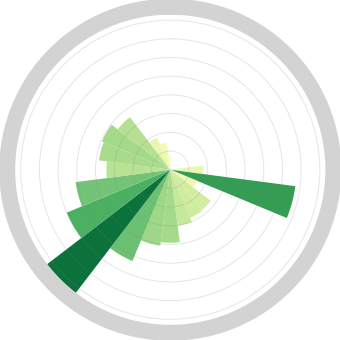

In [128]:
theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)
radii = np.sqrt(hour_matrix.sum())
width = np.pi / 12
colors = plt.cm.YlGn(radii / 10)

ax = plt.subplot(projection='polar')
ax.set_yticklabels([])
ax.set_theta_zero_location('N') 
ax.bar(theta, radii, width=width, bottom=0.0, color=colors)
plt.grid(color='gray', linestyle='-', linewidth=1, alpha=0.2)

# ticks = 
ax.set_xticks([])
# ax.set_xticklabels(["12 AM", "6 AM", "12 PM", "6 PM"])
ax.set_rlabel_position(-22.5)
# ax.tick_params(axis='x', pad=-12)
# ax.tick_params(axis="x", direction="out", pad=-8, zorder=9e99)

# ax.grid(linewidth=9)
plt.setp(ax.spines.values(), linewidth=16, color='lightgrey') 
# plt.setp(ax.get_xticklabels(), zorder=3)

ax.set_theta_direction(-1) 
ax.patch.set_facecolor('none')

show('listening_clock')